# Import libararies and define parameters

In [1]:
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.autograd import Variable

In [2]:
input_size = 784 # Number of input neurons (image pixels)
hidden_size = 400 # Number of hidden neurons
out_size = 10 # Number of class (0-9)
epochs = 10 # How many times we pass our entire dataset into our network
batch_size = 100 # Input size of the data during one iteration
learning_rate = 0.001 # How fast are we learning

# Download MNIST dataset

In [3]:
train_dataset = datasets.MNIST(root='./', train = True,
                               transform = transforms.ToTensor(),
                               download = True)
test_dataset = datasets.MNIST(root='./', train = False,
                               transform = transforms.ToTensor())

torch.Size([1, 28, 28])
Already graycale


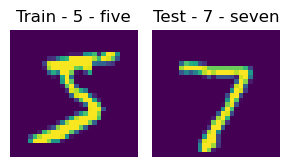

In [34]:
import matplotlib.pyplot as plt

train_img, train_label = train_dataset[0]
test_img, test_label = test_dataset[0]
print(train_img.shape)
print('Already graycale')
# Tạo figure với 1 hàng, 2 cột
fig, axs = plt.subplots(1, 2, figsize=(3, 2))

axs[0].imshow(train_img.permute(1, 2, 0))
axs[0].set_title(f"Train - {train_dataset.classes[train_label]}")
axs[0].axis('off')

axs[1].imshow(test_img.permute(1, 2, 0))
axs[1].set_title(f"Test - {test_dataset.classes[test_label]}")
axs[1].axis('off')

plt.tight_layout()
plt.show()


# Define the network

In [5]:
train_loader  = torch.utils.data.DataLoader(dataset=train_dataset,
                                            batch_size = batch_size,
                                            shuffle = True)
# Shuffle the training data to make it independant of the order

test_loader = torch.utils.data.DataLoader(dataset = test_dataset,
                                          batch_size = batch_size,
                                          shuffle = False)


In [6]:
class Net(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(Net, self).__init__()
        self.fc1  = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size,hidden_size)
        self.fc3 = nn.Linear(hidden_size, out_size)
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        return out
    
net = Net(input_size, hidden_size, out_size)
CUDA = torch.cuda.is_available()
if CUDA:
    net = net.cuda()

# Pytorch: Cross Entropy Loss comes along with Softmax
crieton = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr = learning_rate)

In [7]:
print(net.parameters)
for i, (images, labels) in enumerate(train_loader):
    print(images.size())
    images = images.view(-1,784)
    print(images.size())
    break

<bound method Module.parameters of Net(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=400, out_features=400, bias=True)
  (fc3): Linear(in_features=400, out_features=10, bias=True)
)>
torch.Size([100, 1, 28, 28])
torch.Size([100, 784])


In [13]:
# Train the network
correct_train = 0 
total_train = 0
for epoch in range(epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = Variable(images.view(-1,28*28))
        labels = Variable(labels)
        if CUDA:
            images = images.cuda()
            labels = labels.cuda()

        optimizer.zero_grad()
        outputs = net(images)                      # Forward
        _, predicted = torch.max(outputs.data, 1)  # _ return the proba, predicted return
                                                   # the index location


        total_train += labels.size(0)
        if CUDA:
            correct_train += (predicted.cpu() == labels.cpu()).sum()
        else:
            correct_train += (predicted == labels).sum()

        loss = crieton(outputs, labels)
        loss.backward()
        optimizer.step()

        if (i+1)% 100 == 0:
            print('Epoch [{}/{}], iteration [{}/{}], training loss: {}, training' \
            ' accuracy: {}%'.format(epoch+1, epochs, i+1, len(train_dataset)//batch_size,
            loss.item(), (100*correct_train/total_train)))
        break
print("DONE TRAINING!")


DONE TRAINING!


In [23]:
correct = 0
total = 0
for images, labels in test_loader:
    images = Variable(images.view(-1, 28*28))
    if CUDA:
        images = images.cuda()

    outputs = net(images)
    _, predicted = torch.max(outputs.data,1)
    total += labels.size(0)
    if CUDA: 
        correct += (predicted.cpu() == labels.cpu()).sum()
    else:
        correct += (predicted == labels).sum()

print('Test Accuracy: %d %%' % (100*correct/total))

Test Accuracy: 98 %


# Example outside the dataset

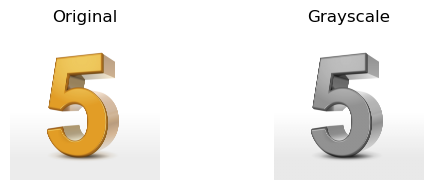

Size before:  (4000, 4000)
Size after:  (4000, 4000)


In [63]:
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

img_before = Image.open("number5.jpg")
img = img_before.convert('L')

# Tạo một figure có 2 subplot trên cùng 1 dòng
fig, axs = plt.subplots(1, 2, figsize=(6, 2))  # 1 hàng, 2 cột

# Hiển thị ảnh gốc
axs[0].imshow(img_before)
axs[0].set_title("Original")
axs[0].axis('off')

# Hiển thị ảnh grayscale
axs[1].imshow(img, cmap='gray')
axs[1].set_title("Grayscale")
axs[1].axis('off')

plt.tight_layout()
plt.show()

print('Size before: ', img_before.size)
print('Size after: ', img.size)


In [53]:
print(img.size)

(4000, 4000)


In [56]:
img = Image.open("number5.jpg")
print(img.size)

# Create transform: Grayscale → Resize → ToTensor
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),  
    transforms.Resize((28, 28)),                  
    transforms.ToTensor()                         
])

# Apply transform
img_tensor = transform(img)
print(img_tensor.shape)  # torch.Size([1, 28, 28])

img_tensor = Variable(img_tensor.view(-1, 28 * 28))
print(img_tensor.shape)  # Kết quả: torch.Size([1, 784])

(4000, 4000)
torch.Size([1, 28, 28])
torch.Size([1, 784])


In [62]:
output = net(img_tensor)
_, predict = torch.max(output.data,1)
print(int(predict.item()))


5
